In [18]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


In [19]:
deaths = pd.read_excel("CovidDeaths.xlsx")
vacc = pd.read_excel("CovidVaccinations.xlsx")

In [20]:
deaths.head()
vacc.head()

,iso_code,continent,location,date,new_tests,total_tests,total_tests_per_thousand,new_tests_per_thousand,new_tests_smoothed,new_tests_smoothed_per_thousand,...,gdp_per_capita,extreme_poverty,cardiovasc_death_rate,diabetes_prevalence,female_smokers,male_smokers,handwashing_facilities,hospital_beds_per_thousand,life_expectancy,human_development_index
0,AFG,Asia,Afghanistan,2020-02-24,NaN,NaN,NaN,NaN,NaN,NaN,...,1803.987,NaN,597.029,9.59,NaN,NaN,37.746,0.5,64.83,0.511
1,AFG,Asia,Afghanistan,2020-02-25,NaN,NaN,NaN,NaN,NaN,NaN,...,1803.987,NaN,597.029,9.59,NaN,NaN,37.746,0.5,64.83,0.511
2,AFG,Asia,Afghanistan,2020-02-26,NaN,NaN,NaN,NaN,NaN,NaN,...,1803.987,NaN,597.029,9.59,NaN,NaN,37.746,0.5,64.83,0.511
3,AFG,Asia,Afghanistan,2020-02-27,NaN,NaN,NaN,NaN,NaN,NaN,...,1803.987,NaN,597.029,9.59,NaN,NaN,37.746,0.5,64.83,0.511
4,AFG,Asia,Afghanistan,2020-02-28,NaN,NaN,NaN,NaN,NaN,NaN,...,1803.987,NaN,597.029,9.59,NaN,NaN,37.746,0.5,64.83,0.511


In [21]:
deaths.shape
vacc.shape

(85171, 37)

In [22]:
deaths.columns
vacc.columns

Index(['iso_code', 'continent', 'location', 'date', 'new_tests', 'total_tests',
       'total_tests_per_thousand', 'new_tests_per_thousand',
       'new_tests_smoothed', 'new_tests_smoothed_per_thousand',
       'positive_rate', 'tests_per_case', 'tests_units', 'total_vaccinations',
       'people_vaccinated', 'people_fully_vaccinated', 'new_vaccinations',
       'new_vaccinations_smoothed', 'total_vaccinations_per_hundred',
       'people_vaccinated_per_hundred', 'people_fully_vaccinated_per_hundred',
       'new_vaccinations_smoothed_per_million', 'stringency_index',
       'population_density', 'median_age', 'aged_65_older', 'aged_70_older',
       'gdp_per_capita', 'extreme_poverty', 'cardiovasc_death_rate',
       'diabetes_prevalence', 'female_smokers', 'male_smokers',
       'handwashing_facilities', 'hospital_beds_per_thousand',
       'life_expectancy', 'human_development_index'],
      dtype='object')

In [23]:
deaths.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 85171 entries, 0 to 85170
Data columns (total 59 columns):
 #   Column                                 Non-Null Count  Dtype         
---  ------                                 --------------  -----         
 0   iso_code                               85171 non-null  object        
 1   continent                              81060 non-null  object        
 2   location                               85171 non-null  object        
 3   date                                   85171 non-null  datetime64[ns]
 4   total_cases                            83072 non-null  float64       
 5   new_cases                              83070 non-null  float64       
 6   new_cases_smoothed                     82069 non-null  float64       
 7   total_deaths                           73408 non-null  float64       
 8   new_deaths                             73566 non-null  float64       
 9   new_deaths_smoothed                    82069 non-null  float6

In [24]:
deaths.isnull().sum()

,0
iso_code,0
continent,4111
location,0
date,0
total_cases,2099
new_cases,2101
new_cases_smoothed,3102
total_deaths,11763
new_deaths,11605
new_deaths_smoothed,3102


In [25]:
deaths['location'].nunique()

219

In [26]:
deaths['date'].min(),deaths['date'].max()

(Timestamp('2020-01-01 00:00:00'), Timestamp('2021-04-30 00:00:00'))

In [27]:
deaths['date']=pd.to_datetime(deaths['date'])

In [28]:
deaths.dtypes

,0
iso_code,object
continent,object
location,object
date,datetime64[ns]
total_cases,float64
new_cases,float64
new_cases_smoothed,float64
total_deaths,float64
new_deaths,float64
new_deaths_smoothed,float64


In [29]:
deaths.duplicated().sum()

np.int64(0)

In [30]:
deaths = deaths.drop_duplicates()

In [31]:
deaths = deaths[deaths['continent'].notnull()]

In [32]:
deaths = deaths[['continent','location','date','population',
                 'total_cases','new_cases',
                 'total_deaths','new_deaths']]

In [33]:
deaths['total_cases'] = deaths['total_cases'].fillna(0)
deaths['total_deaths'] = deaths['total_deaths'].fillna(0)
deaths['new_cases'] = deaths['new_cases'].fillna(0)
deaths['new_deaths'] = deaths['new_deaths'].fillna(0)

In [34]:
deaths.isnull().sum()

,0
continent,0
location,0
date,0
population,100
total_cases,0
new_cases,0
total_deaths,0
new_deaths,0


In [35]:
deaths = deaths[deaths['continent'].notnull()]

In [36]:
deaths.shape

(81060, 8)

In [37]:
deaths = deaths[['continent','location','date','population',
                 'total_cases','new_cases',
                 'total_deaths','new_deaths']]

In [38]:
deaths.head()

,continent,location,date,population,total_cases,new_cases,total_deaths,new_deaths
0,Asia,Afghanistan,2020-02-24,38928341.0,1.0,1.0,0.0,0.0
1,Asia,Afghanistan,2020-02-25,38928341.0,1.0,0.0,0.0,0.0
2,Asia,Afghanistan,2020-02-26,38928341.0,1.0,0.0,0.0,0.0
3,Asia,Afghanistan,2020-02-27,38928341.0,1.0,0.0,0.0,0.0
4,Asia,Afghanistan,2020-02-28,38928341.0,1.0,0.0,0.0,0.0


In [39]:
# Countries having higher number of COVID Cases
deaths.groupby('location')['total_cases'].max().sort_values(ascending=False).head(10)

,total_cases
location,
United States,32346971.0
India,19164969.0
Brazil,14659011.0
France,5677835.0
Turkey,4820591.0
Russia,4750755.0
United Kingdom,4432246.0
Italy,4022653.0
Spain,3524077.0


In [40]:
# Death Percentages
deaths['death_percentage'] = (deaths['total_deaths'] / deaths['total_cases']) * 100
deaths = deaths[deaths['total_cases'] > 0]


In [41]:
deaths[['location','total_cases','total_deaths','death_percentage']].head()

,location,total_cases,total_deaths,death_percentage
0,Afghanistan,1.0,0.0,0.0
1,Afghanistan,1.0,0.0,0.0
2,Afghanistan,1.0,0.0,0.0
3,Afghanistan,1.0,0.0,0.0
4,Afghanistan,1.0,0.0,0.0


In [42]:
deaths.groupby('location')['death_percentage'].max().sort_values(ascending=False).head(10)

,death_percentage
location,
Iran,100.000000
Guyana,100.000000
Sudan,100.000000
Guatemala,50.000000
Gambia,50.000000
Nicaragua,50.000000
Philippines,50.000000
Morocco,33.333333
Gabon,33.333333


In [43]:
# Infection Perecentage
country_infection = deaths.groupby('location').agg({
    'population':'max',
    'total_cases':'max'
})

country_infection['infection_rate'] = (country_infection['total_cases'] / country_infection['population']) * 100

country_infection.sort_values('infection_rate', ascending=False).head(10)

,population,total_cases,infection_rate
location,,,
Andorra,77265.0,13232.0,17.125477
Montenegro,628062.0,97389.0,15.506272
Czechia,10708982.0,1630758.0,15.227946
San Marino,33938.0,5066.0,14.927220
Slovenia,2078932.0,240292.0,11.558435
Luxembourg,625976.0,67205.0,10.736035
Bahrain,1701583.0,176934.0,10.398200
Serbia,6804596.0,689557.0,10.133695
United States,331002647.0,32346971.0,9.772421


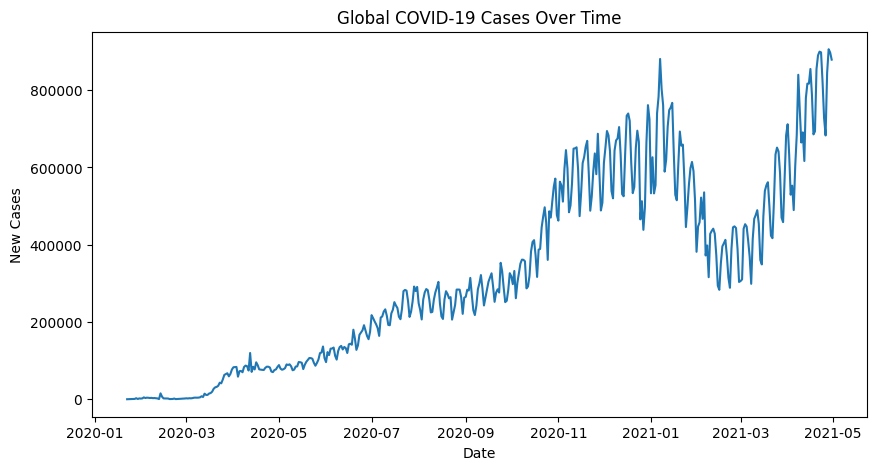

In [44]:
global_cases = deaths.groupby('date')['new_cases'].sum()

import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))
plt.plot(global_cases)
plt.title("Global COVID-19 Cases Over Time")
plt.xlabel("Date")
plt.ylabel("New Cases")
plt.show()

In [45]:
import pandas as pd

deaths = pd.read_excel("CovidDeaths.xlsx")
vaccinations = pd.read_excel("CovidVaccinations.xlsx")

In [46]:
deaths.columns
vaccinations.columns

Index(['iso_code', 'continent', 'location', 'date', 'new_tests', 'total_tests',
       'total_tests_per_thousand', 'new_tests_per_thousand',
       'new_tests_smoothed', 'new_tests_smoothed_per_thousand',
       'positive_rate', 'tests_per_case', 'tests_units', 'total_vaccinations',
       'people_vaccinated', 'people_fully_vaccinated', 'new_vaccinations',
       'new_vaccinations_smoothed', 'total_vaccinations_per_hundred',
       'people_vaccinated_per_hundred', 'people_fully_vaccinated_per_hundred',
       'new_vaccinations_smoothed_per_million', 'stringency_index',
       'population_density', 'median_age', 'aged_65_older', 'aged_70_older',
       'gdp_per_capita', 'extreme_poverty', 'cardiovasc_death_rate',
       'diabetes_prevalence', 'female_smokers', 'male_smokers',
       'handwashing_facilities', 'hospital_beds_per_thousand',
       'life_expectancy', 'human_development_index'],
      dtype='object')

In [47]:
covid_data = pd.merge(
    deaths,
    vaccinations,
    on=["location", "date"],
    how="inner"
)

In [48]:
covid_data.head()

,iso_code_x,continent_x,location,date,total_cases,new_cases,new_cases_smoothed,total_deaths,new_deaths,new_deaths_smoothed,...,gdp_per_capita_y,extreme_poverty_y,cardiovasc_death_rate_y,diabetes_prevalence_y,female_smokers_y,male_smokers_y,handwashing_facilities_y,hospital_beds_per_thousand_y,life_expectancy_y,human_development_index_y
0,AFG,Asia,Afghanistan,2020-02-24,1.0,1.0,NaN,NaN,NaN,NaN,...,1803.987,NaN,597.029,9.59,NaN,NaN,37.746,0.5,64.83,0.511
1,AFG,Asia,Afghanistan,2020-02-25,1.0,0.0,NaN,NaN,NaN,NaN,...,1803.987,NaN,597.029,9.59,NaN,NaN,37.746,0.5,64.83,0.511
2,AFG,Asia,Afghanistan,2020-02-26,1.0,0.0,NaN,NaN,NaN,NaN,...,1803.987,NaN,597.029,9.59,NaN,NaN,37.746,0.5,64.83,0.511
3,AFG,Asia,Afghanistan,2020-02-27,1.0,0.0,NaN,NaN,NaN,NaN,...,1803.987,NaN,597.029,9.59,NaN,NaN,37.746,0.5,64.83,0.511
4,AFG,Asia,Afghanistan,2020-02-28,1.0,0.0,NaN,NaN,NaN,NaN,...,1803.987,NaN,597.029,9.59,NaN,NaN,37.746,0.5,64.83,0.511


In [49]:
covid_data.shape

(85171, 94)

In [50]:
covid_data.columns

Index(['iso_code_x', 'continent_x', 'location', 'date', 'total_cases',
       'new_cases', 'new_cases_smoothed', 'total_deaths', 'new_deaths',
       'new_deaths_smoothed', 'total_cases_per_million',
       'new_cases_per_million', 'new_cases_smoothed_per_million',
       'total_deaths_per_million', 'new_deaths_per_million',
       'new_deaths_smoothed_per_million', 'reproduction_rate', 'icu_patients',
       'icu_patients_per_million', 'hosp_patients',
       'hosp_patients_per_million', 'weekly_icu_admissions',
       'weekly_icu_admissions_per_million', 'weekly_hosp_admissions',
       'weekly_hosp_admissions_per_million', 'new_tests_x', 'total_tests_x',
       'total_tests_per_thousand_x', 'new_tests_per_thousand_x',
       'new_tests_smoothed_x', 'new_tests_smoothed_per_thousand_x',
       'positive_rate_x', 'tests_per_case_x', 'tests_units_x',
       'total_vaccinations_x', 'people_vaccinated_x',
       'people_fully_vaccinated_x', 'new_vaccinations_x',
       'new_vaccinations_s

In [51]:
covid_data = covid_data[
    [
        "continent_x",
        "location",
        "date",
        "total_cases",
        "new_cases",
        "total_deaths",
        "new_deaths",
        "people_vaccinated_x",
        "people_fully_vaccinated_x",
        "new_vaccinations_x",
        "population"
    ]
]

In [52]:
covid_data.rename(columns={
    "continent_x": "continent",
    "people_vaccinated_x": "people_vaccinated",
    "people_fully_vaccinated_x": "people_fully_vaccinated",
    "new_vaccinations_x": "new_vaccinations"
}, inplace=True)

In [53]:
covid_data.head()

,continent,location,date,total_cases,new_cases,total_deaths,new_deaths,people_vaccinated,people_fully_vaccinated,new_vaccinations,population
0,Asia,Afghanistan,2020-02-24,1.0,1.0,NaN,NaN,NaN,NaN,NaN,38928341.0
1,Asia,Afghanistan,2020-02-25,1.0,0.0,NaN,NaN,NaN,NaN,NaN,38928341.0
2,Asia,Afghanistan,2020-02-26,1.0,0.0,NaN,NaN,NaN,NaN,NaN,38928341.0
3,Asia,Afghanistan,2020-02-27,1.0,0.0,NaN,NaN,NaN,NaN,NaN,38928341.0
4,Asia,Afghanistan,2020-02-28,1.0,0.0,NaN,NaN,NaN,NaN,NaN,38928341.0


In [54]:
# Death Percentage
covid_data["death_percentage"] = (covid_data["total_deaths"] / covid_data["total_cases"]) * 100

In [55]:
# Vaccination Percentages
covid_data["vaccination_percentage"] = (covid_data["people_fully_vaccinated"] / covid_data["population"]) * 100

In [56]:
#Cases per population
covid_data["cases_percentage"] = (covid_data["total_cases"] / covid_data["population"]) * 100

In [57]:
covid_data["rolling_vaccinations"] = covid_data.groupby("location")["new_vaccinations"].cumsum()

In [58]:
covid_data["rolling_vaccinations"] = (
    covid_data.groupby("location")["new_vaccinations"].cumsum()
)

In [59]:
covid_data[["location","date","new_vaccinations","rolling_vaccinations"]].head(20)

,location,date,new_vaccinations,rolling_vaccinations
0,Afghanistan,2020-02-24,NaN,NaN
1,Afghanistan,2020-02-25,NaN,NaN
2,Afghanistan,2020-02-26,NaN,NaN
3,Afghanistan,2020-02-27,NaN,NaN
4,Afghanistan,2020-02-28,NaN,NaN
5,Afghanistan,2020-02-29,NaN,NaN
6,Afghanistan,2020-03-01,NaN,NaN
7,Afghanistan,2020-03-02,NaN,NaN
8,Afghanistan,2020-03-03,NaN,NaN
9,Afghanistan,2020-03-04,NaN,NaN


In [60]:
top_vaccinated = covid_data.groupby("location")["people_fully_vaccinated"].max().sort_values(ascending=False).head(10)

top_vaccinated

,people_fully_vaccinated
location,
World,268002541.0
North America,111054793.0
United States,101407318.0
Europe,64402785.0
Asia,63142140.0
European Union,39276085.0
India,26621155.0
South America,24466638.0
United Kingdom,14532875.0


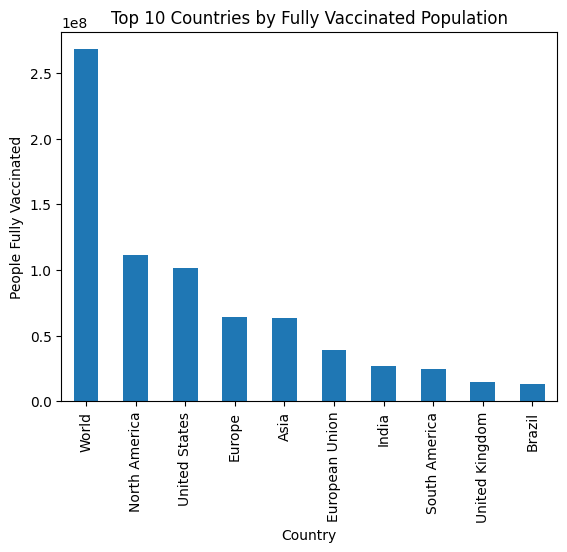

In [61]:
import matplotlib.pyplot as plt

top_vaccinated.plot(kind="bar")

plt.title("Top 10 Countries by Fully Vaccinated Population")
plt.xlabel("Country")
plt.ylabel("People Fully Vaccinated")
plt.show()

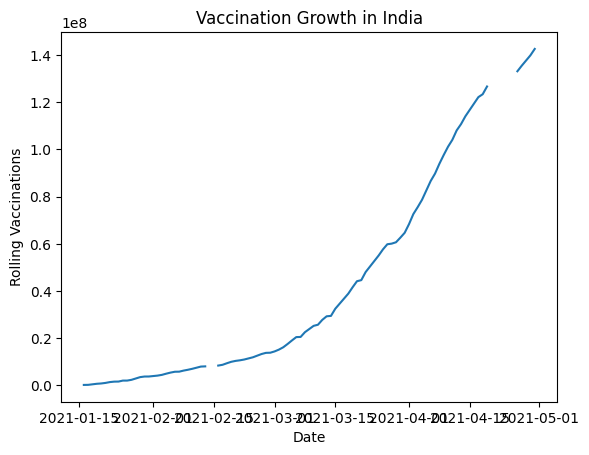

In [62]:
india = covid_data[covid_data["location"] == "India"]

plt.figure()
plt.plot(india["date"], india["rolling_vaccinations"])

plt.title("Vaccination Growth in India")
plt.xlabel("Date")
plt.ylabel("Rolling Vaccinations")
plt.show()

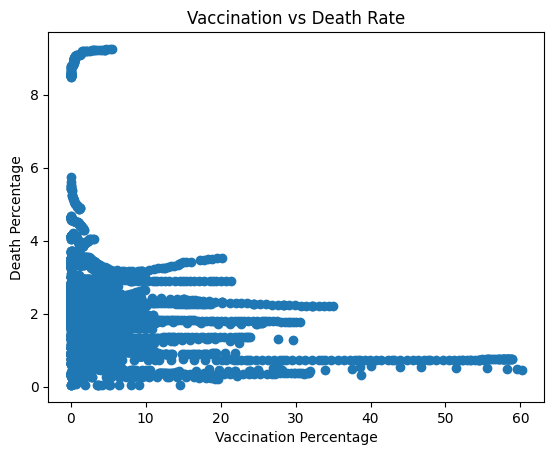

In [63]:
plt.figure()

plt.scatter(
    covid_data["vaccination_percentage"],
    covid_data["death_percentage"]
)

plt.xlabel("Vaccination Percentage")
plt.ylabel("Death Percentage")
plt.title("Vaccination vs Death Rate")

plt.show()

In [64]:
infection_rate = (
    covid_data.groupby("location")
    .apply(lambda x: (x["total_cases"] / x["population"]).max() * 100)
    .sort_values(ascending=False)
    .head(10)
)

infection_rate

/tmp/ipykernel_348/4194208425.py:3: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: (x["total_cases"] / x["population"]).max() * 100)


,0
location,
Andorra,17.125477
Montenegro,15.506272
Czechia,15.227946
San Marino,14.927220
Slovenia,11.558435
Luxembourg,10.736035
Bahrain,10.398200
Serbia,10.133695
United States,9.772421


<Axes: title={'center': 'Top Countries by Infection Rate'}, xlabel='location'>

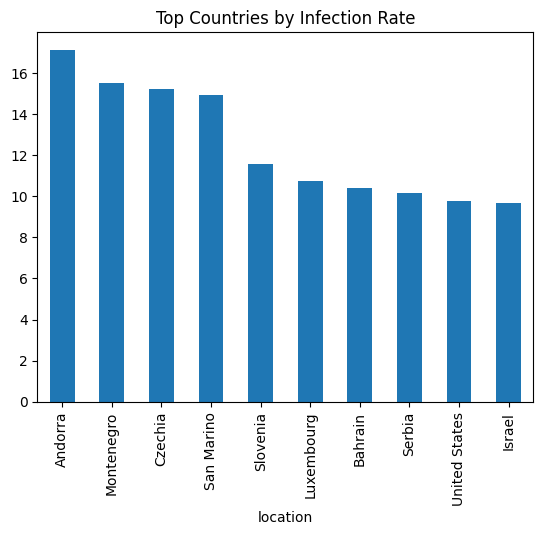

In [65]:
infection_rate.plot(kind="bar", title="Top Countries by Infection Rate")

In [66]:
highest_deaths = (
    covid_data.groupby("location")["total_deaths"]
    .max()
    .sort_values(ascending=False)
    .head(10)
)

highest_deaths

,total_deaths
location,
World,3180238.0
Europe,1016750.0
North America,847942.0
European Union,688896.0
South America,672415.0
United States,576232.0
Asia,520286.0
Brazil,403781.0
Mexico,216907.0


<Axes: title={'center': 'Countries with Highest Death Count'}, xlabel='location'>

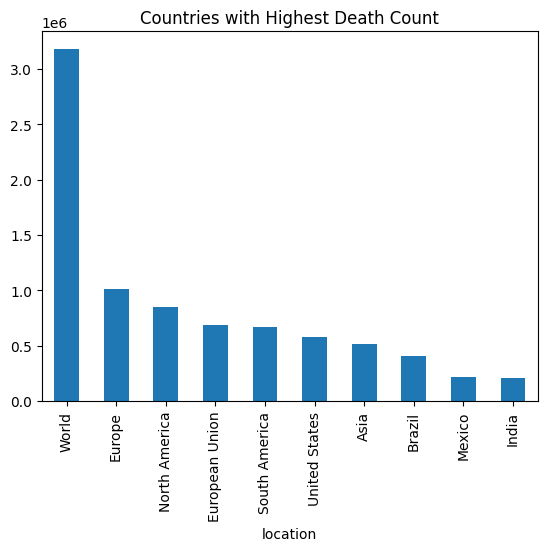

In [67]:
highest_deaths.plot(kind="bar", title="Countries with Highest Death Count")

In [68]:
death_rate_country = (
    covid_data.groupby("location")
    .apply(lambda x: (x["total_deaths"].max() / x["total_cases"].max()) * 100)
    .sort_values(ascending=False)
    .head(10)
)

death_rate_country

/tmp/ipykernel_348/4131099541.py:3: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: (x["total_deaths"].max() / x["total_cases"].max()) * 100)


,0
location,
Vanuatu,25.000000
Yemen,19.407947
Mexico,9.250732
Syria,7.003035
Sudan,6.920222
Egypt,5.861957
Somalia,5.123967
Ecuador,4.878988
China,4.727106


In [69]:
vacc_progress = (
    covid_data.groupby("location")["vaccination_percentage"]
    .max()
    .sort_values(ascending=False)
    .head(10)
)

vacc_progress

,vaccination_percentage
location,
Gibraltar,97.468167
Seychelles,60.158633
Israel,58.839280
Falkland Islands,50.961815
Cayman Islands,45.526476
United Arab Emirates,38.790352
Bermuda,38.178665
Chile,35.015755
Bahrain,31.837824


<Axes: title={'center': 'Top Countries by Vaccination Percentage'}, xlabel='location'>

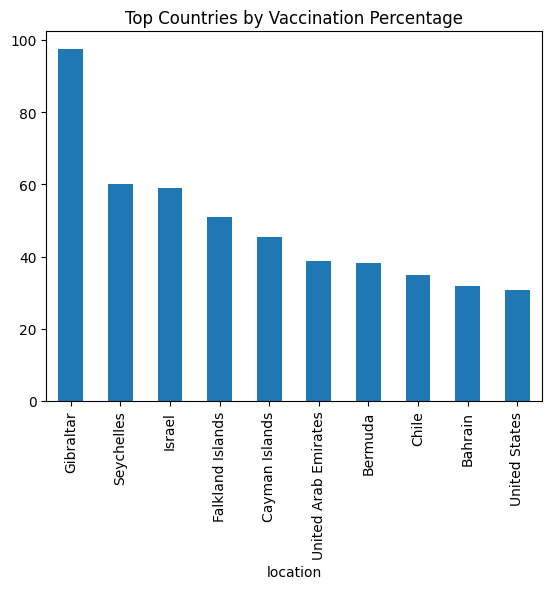

In [70]:
vacc_progress.plot(kind="bar", title="Top Countries by Vaccination Percentage")

In [71]:
global_trend = covid_data.groupby("date")[["new_cases","new_deaths"]].sum()

<Axes: title={'center': 'Global COVID Trend Over Time'}, xlabel='date'>

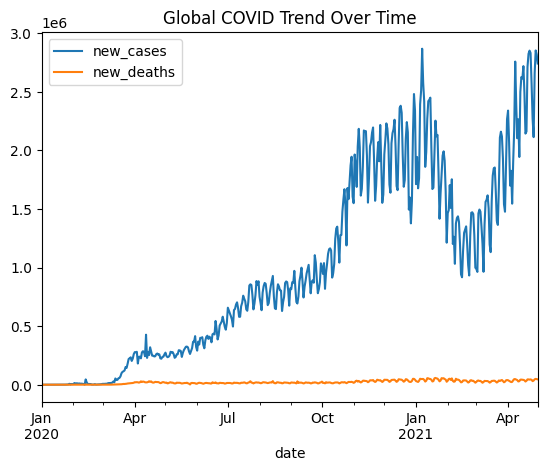

In [72]:
global_trend.plot(title="Global COVID Trend Over Time")

<Axes: title={'center': 'Total Cases by Continent'}, xlabel='continent'>

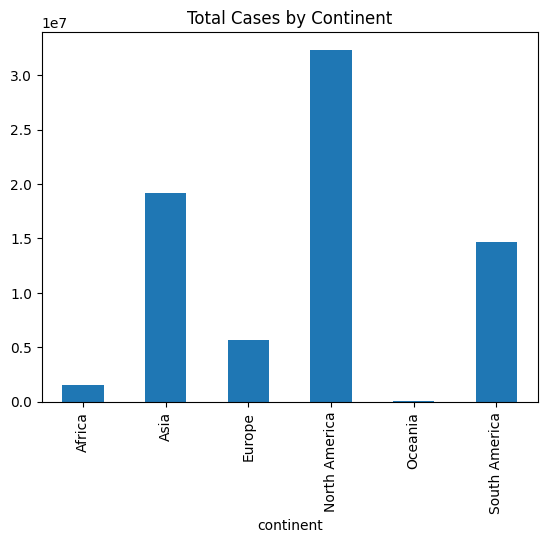

In [73]:
continent_cases = covid_data.groupby("continent")["total_cases"].max()

continent_cases.plot(kind="bar", title="Total Cases by Continent")

In [74]:
covid_data.to_csv("covid_final_analysis.csv", index=False)